# CEF deep-dive: Oxford Lane at the center

Thin driver notebook: all logic lives in `src/cef/`. Framing: listed CLO closed-end funds (Oxford Lane Capital Corp., OXLC, at the center; Eagle Point Credit, ECC, alongside) are **permanent capital that converts retail demand into primary CLO equity orders** — their capital formation is upstream of CLO formation.

**The centerpiece — the premium-funded ATM flywheel, and its 2025-2026 reversal** (`analysis_capital_machine.py`, `viz_flywheel.py`, `scrape_nav_press_releases.py`): a desk question ("if this isn't verified, it shouldn't be here" / "do the same to Oxford Lane" as was done for the anatomy section's warehouse chart) prompted a search for better data than this notebook originally had, and found it. OXLC's own EDGAR 424B3/497 prospectus supplements disclose exact ATM shares sold and proceeds plus a preliminary NAV-per-share estimate — but that channel goes quiet whenever ATM issuance does, and it stopped in May 2025. A second, previously-unused real channel doesn't have that problem: OXLC issues its own monthly and quarterly NAV-update **press releases** (GlobeNewswire, publicly distributed, independent of ATM activity), which this notebook now scrapes and merges with the ATM-supplement series. The combined, real series is decisive: **every month-end since July 2025 has shown a discount, not a premium** — a full reversal from the persistent premium every earlier disclosure showed, sustained for 10 straight months through the most recent (May 2026) release. New ATM issuance at a discount is NAV-dilutive, the opposite of the premium-funded mechanic this section is built around — see the flywheel exhibit below for the full read, including why the ATM-issuance panel goes quiet exactly when the discount starts.

**Two real bugs, caught and fixed along the way**: (1) OXLC underwent a 1-for-5 reverse split on 2025-09-08. Yahoo Finance's historical "Close" price turned out to be retroactively split-adjusted (not just dividend-adjusted, despite the naming), while the scraped NAV disclosures were not — the first pass through this pipeline produced a nonsense 813% "premium" for April 2020 before the mismatch was traced and fixed (`scrape_preferreds.scrape_stock_splits`, `analysis_capital_machine._cumulative_split_factor`). (2) Adding the press-release channel surfaced a second, related bug: a press release published *after* the split restates its own prior-period comparison figures on the *current* share basis already, so keying the same split-rescale off the as-of date (correct for the 424B3 channel, which is always contemporaneous) double-counted the split for press-release rows and inflated one real data point ($20.60 -> a nonsense $103.00). Fixed by keying the rescale off each figure's *publication* date instead of its as-of date. Both bugs have regression tests in `tests/test_analysis_capital_machine.py`.

**Extends into**: cost of capital (preferred/baby-bond yields vs. portfolio effective yield), distribution-cut resilience (does the premium survive a cut?), portfolio shelf/vintage concentration (NPORT-P), the NAV-translation leverage gradient (JAAA -> BKLN -> OXLC/ECC, teaching the whole capital structure through instruments a desk can quote), and a 13G-based institutional-ownership floor.

**Documented gap**: the demand-transmission chain's final link (issuance -> market-wide CLO new-issue equity conditions) needs Section 4's CLO issuance-cycle data, which is empty (SIFMA gated) — reported as a gap in `analysis_demand_transmission.py`, not silently dropped.


## What Oxford Lane actually publishes, and what it doesn't

Matching the same treatment applied to the anatomy section's warehouse-ramp chart: a plain accounting of
what's real and publicly available for this fund versus what isn't, rather than one undifferentiated
TO-VERIFY label. Oxford Lane is a much more transparent subject than a private CLO warehouse -- it is a
NYSE-listed registered closed-end fund with real, ongoing disclosure obligations -- but "more transparent"
still has real edges.

**Published, and used in this notebook:**

| What | Frequency | Channel | Used in |
|---|---|---|---|
| ATM shares sold, net proceeds | Per supplement (irregular, tied to issuance) | EDGAR 424B3/497 "prior sales" paragraphs | `viz_flywheel` (issuance panels) |
| Preliminary NAV-per-share estimate | Same supplements, when a "financial update" paragraph is present | EDGAR 424B3/497 | `viz_flywheel` (premium panel, gray points) |
| Monthly NAV-per-share estimate (range) | Monthly | OXLC's own press releases (GlobeNewswire) | `viz_flywheel` (premium panel, red points) -- new this pass |
| Quarterly NAV-per-share (actual) + declared distributions | Quarterly | Same press-release channel, combined with earnings | `viz_flywheel` (premium panel, red points) -- new this pass |
| Portfolio holdings, total net assets | Quarterly | NPORT-P (structured XML, SEC-mandated for all registered funds) | `latest_nav_estimate()` cross-check; `analysis_portfolio*.py` |
| Dividend/distribution history | Per declaration | Yahoo Finance corporate-action history (mirrors the press releases) | `scrape_prices_nav.scrape_distributions` |
| Institutional ownership floor | Per Schedule 13G/13D filer | EDGAR full-text search | `analysis_ownership.py` |

**Not published, or not accessible to this project:**

| What | Why | This notebook's response |
|---|---|---|
| Daily/real-time NAV | Closed-end funds are not required to strike a daily NAV the way open-end mutual funds are; OXLC discloses monthly estimates and quarterly actuals only | Premium/discount is only ever computed *at* a disclosed NAV date, never interpolated between them |
| A machine-readable archive/index of OXLC's own press releases | Both `ir.oxfordlanecapital.com`'s news-releases page and GlobeNewswire's own organization-search page are client-rendered (JavaScript) -- confirmed by fetching each directly: the IR site times out on every retry, GlobeNewswire's raw HTML returns an app shell with no article links | `scrape_nav_press_releases.py`'s URL list is manually curated from search results (documented in the module's own docstring), the same way the anatomy section's single circular URL was found -- not auto-discovered, and won't pick up new releases without someone adding the URL |
| Full look-through detail on every underlying CLO tranche OXLC holds | NPORT-P gives position-level CUSIP/fair-value/coupon, not the underlying loan pool each CLO tranche references | `analysis_portfolio*.py` works at the tranche level NPORT-P actually discloses, not a synthetic look-through |
| Confirmation that the discount shown here is *why* ATM issuance stopped (vs. some other reason) | OXLC does not publish its own reasoning for pausing issuance | Stated as a consistency observation in the flywheel exhibit ("this is consistent with"), not asserted as the confirmed cause |

The practical upshot is the same as the anatomy section's: this fund is far more transparent than a
private CLO warehouse, but "transparent" still has a specific, checkable boundary, and the flywheel
exhibit below is now built to sit right up against that boundary rather than falling short of it (the
May 2025 cutoff the disclosure trail used to have) or overstating it (treating a single derived estimate
as equivalent to the fund's own published numbers, which the prior pass did with the NPORT-P diamond
marker -- removed now that real disclosed data covers the same period more authoritatively).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

from IPython.display import Image, display

from src.cef import (
    scrape_capital_actions, scrape_preferreds, scrape_13f_ownership,
    analysis_capital_machine, analysis_cost_of_capital, analysis_distribution_quality,
    analysis_portfolio_style, analysis_nav_translation, analysis_ownership, analysis_demand_transmission,
    viz_flywheel, viz_cost_of_capital, viz_distribution, viz_style, viz_wrapper,
    ledger,
)


/Users/zinuoshi/clo-atlas/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Scrape (raw -> interim)

In [2]:
RUN_SCRAPE = False
if RUN_SCRAPE:
    scrape_capital_actions.run()   # ATM tape, preferred series, NAV disclosures — from EDGAR 424B3/497
    scrape_preferreds.run()        # preferred/baby-bond prices + stock-split history
    scrape_13f_ownership.run()     # Schedule 13G/13G-A


## Analysis (interim -> final)

In [3]:
capital_machine = analysis_capital_machine.run()
cost_of_capital = analysis_cost_of_capital.run()
distribution_quality = analysis_distribution_quality.run()
portfolio_style = analysis_portfolio_style.run()
nav_translation = analysis_nav_translation.run()
ownership = analysis_ownership.run()
demand_transmission = analysis_demand_transmission.run()


## Viz (final -> figures/)

/Users/zinuoshi/clo-atlas/src/cef/viz_wrapper.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([LABELS[t] for t in merged["ticker"]], fontsize=8.5)
/Users/zinuoshi/clo-atlas/src/cef/viz_wrapper.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels([LABELS[t] for t in merged["ticker"]], fontsize=8.5)


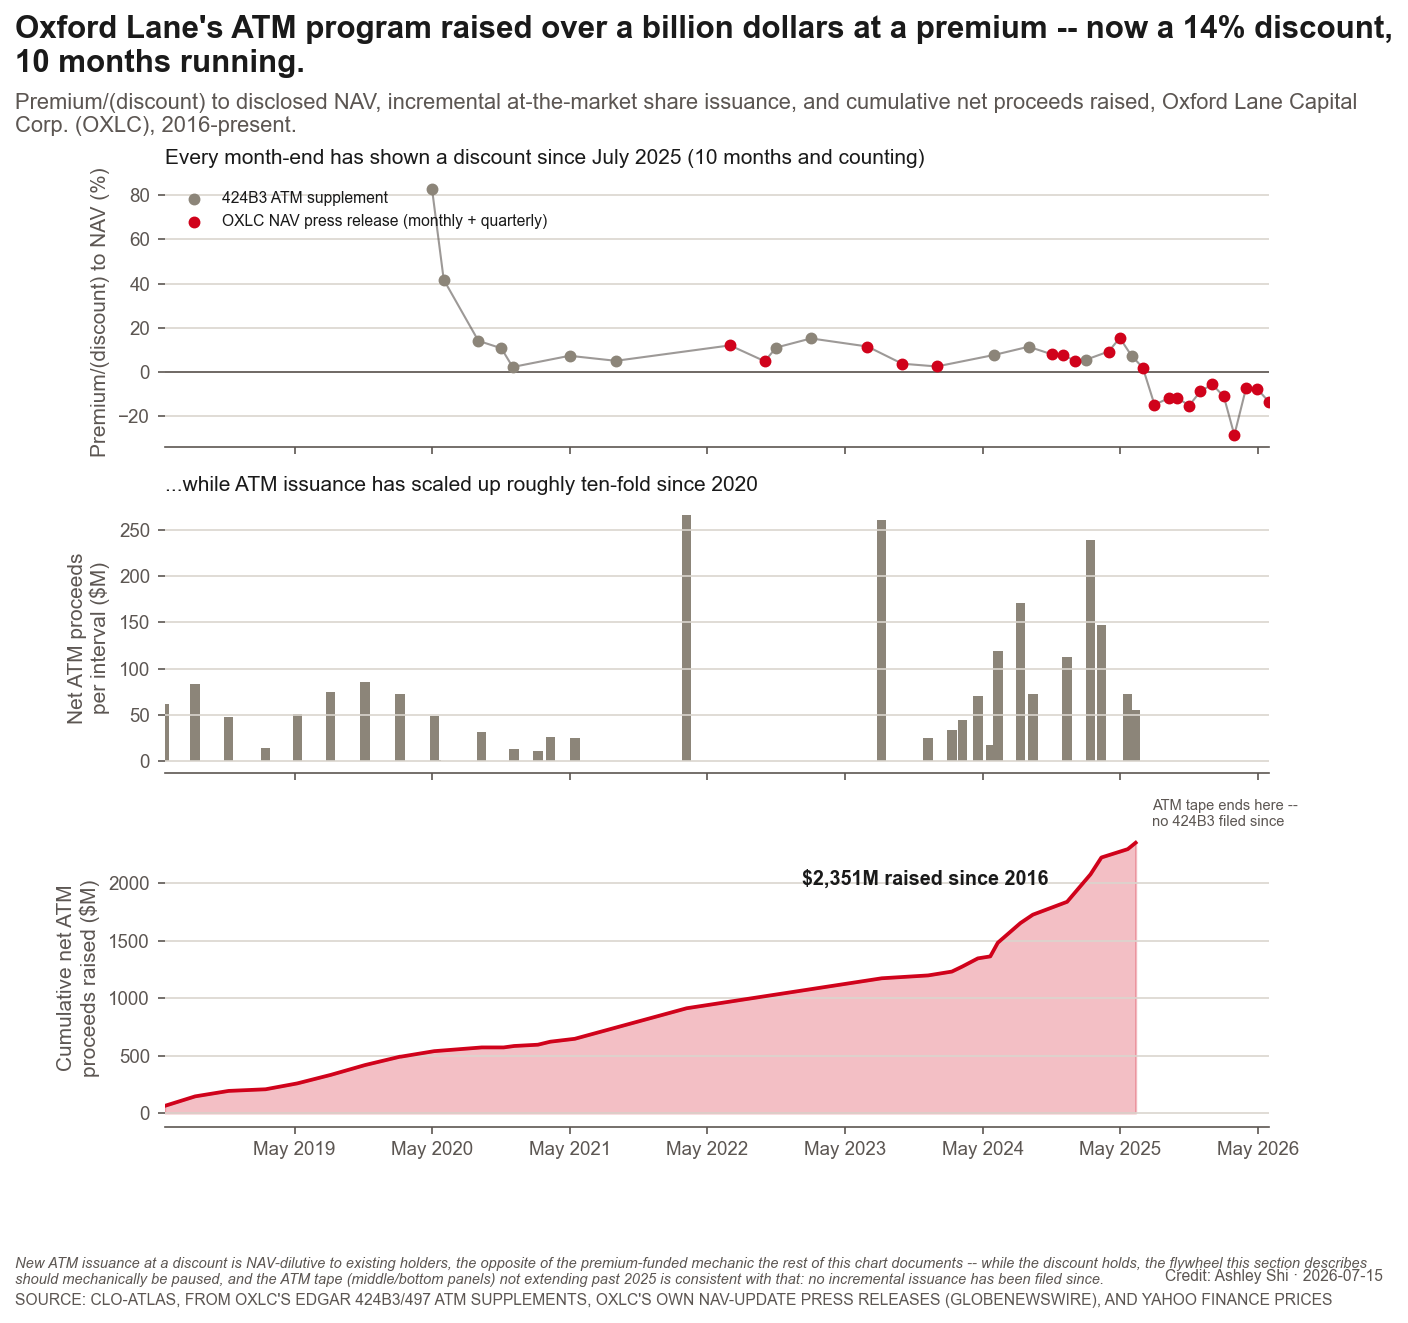

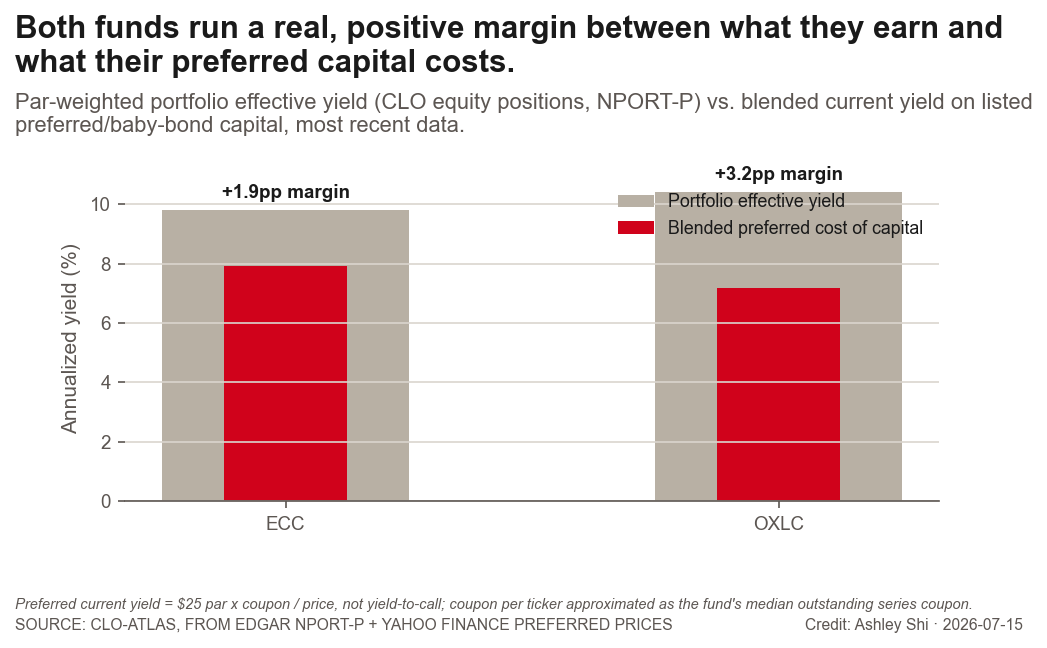

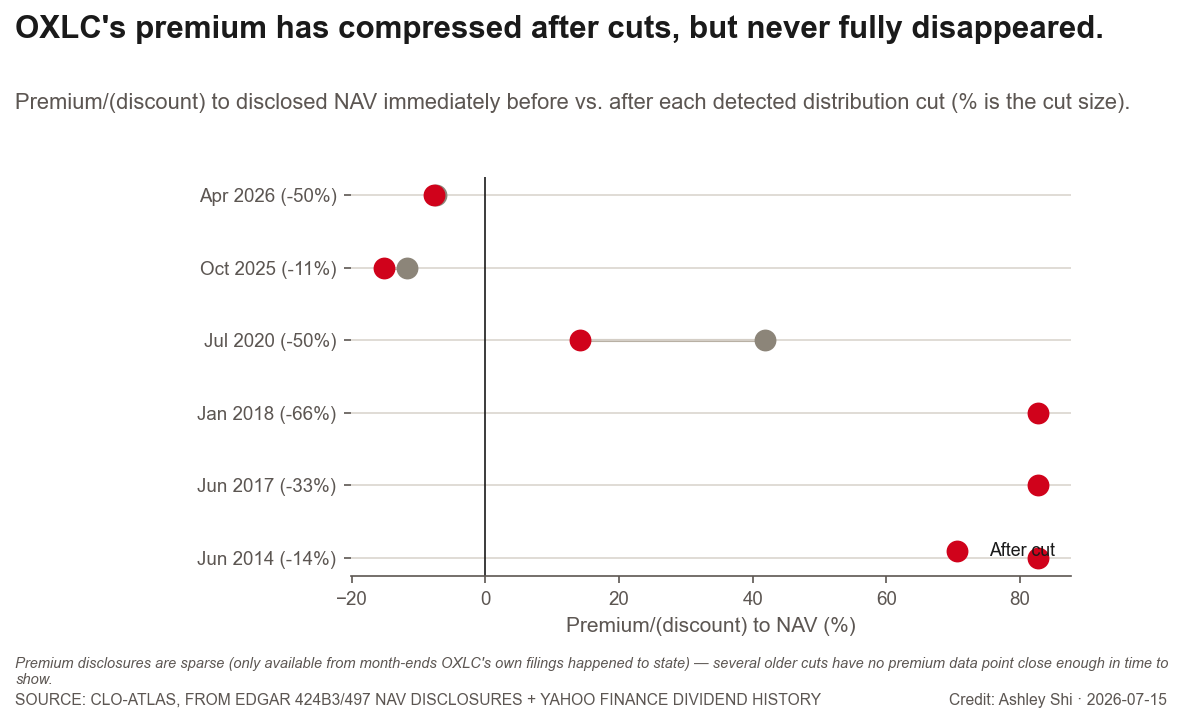

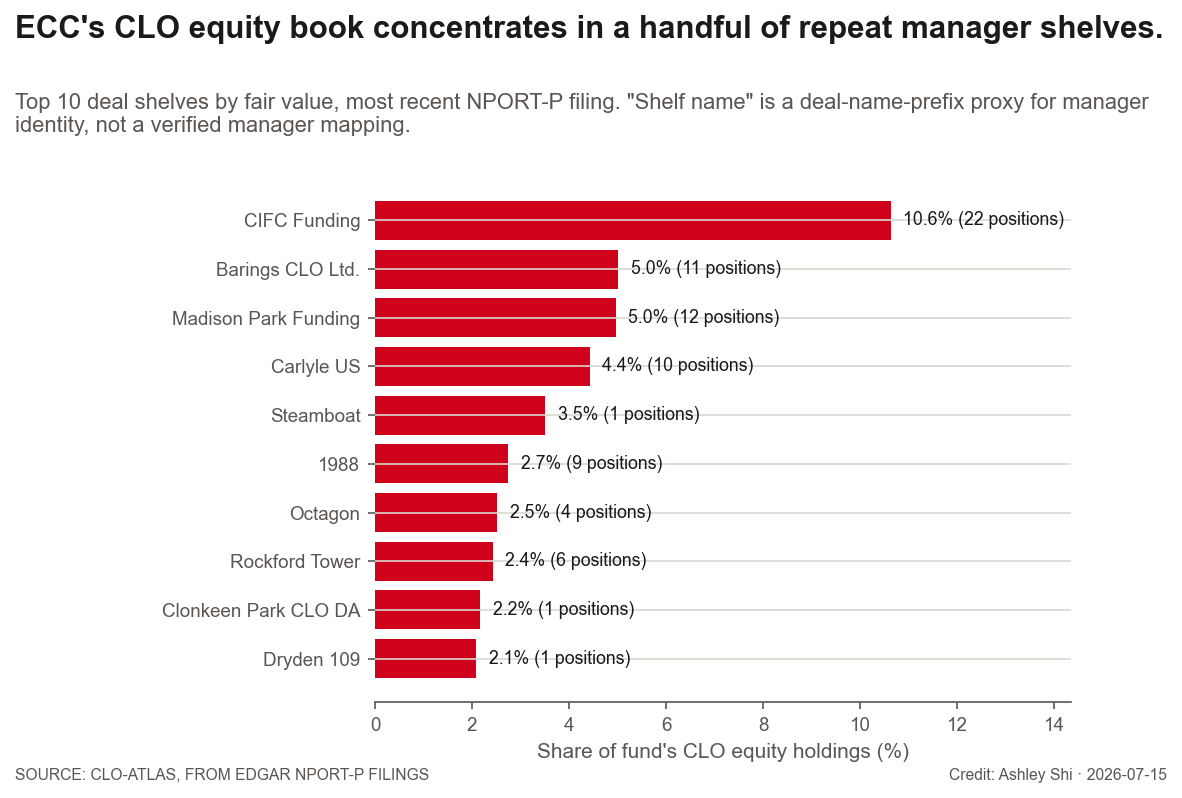

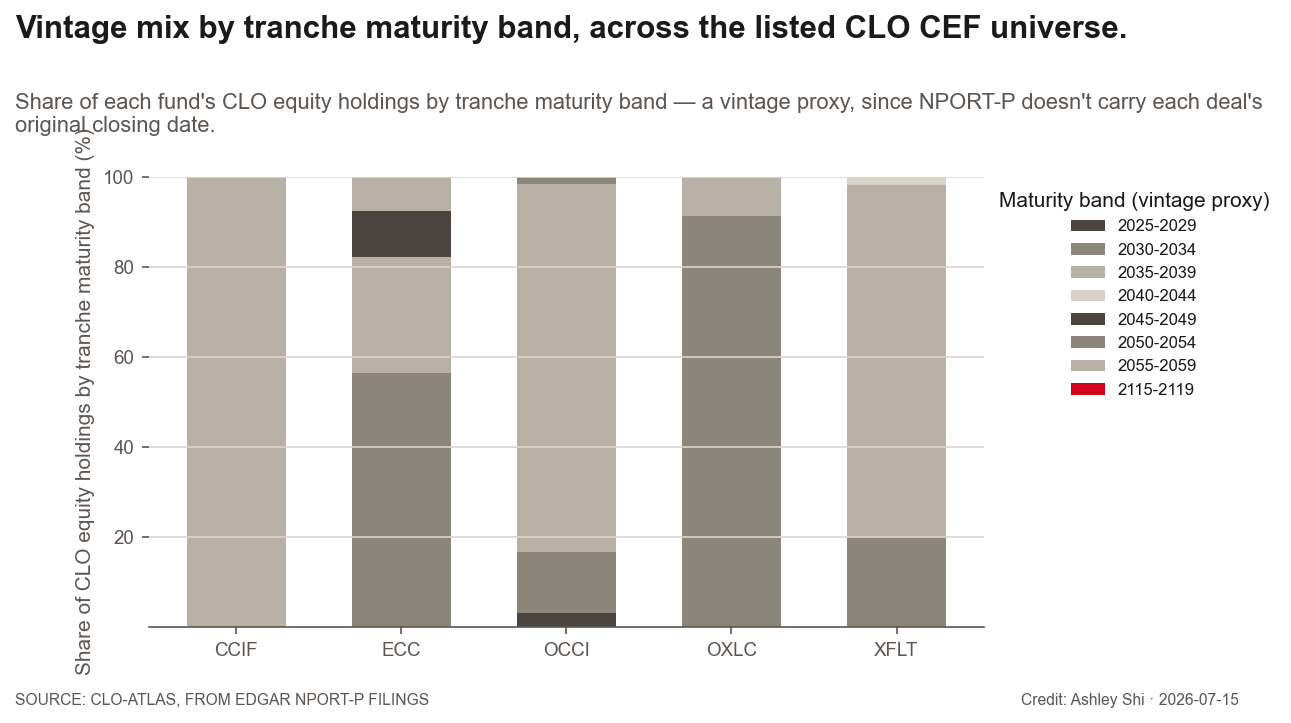

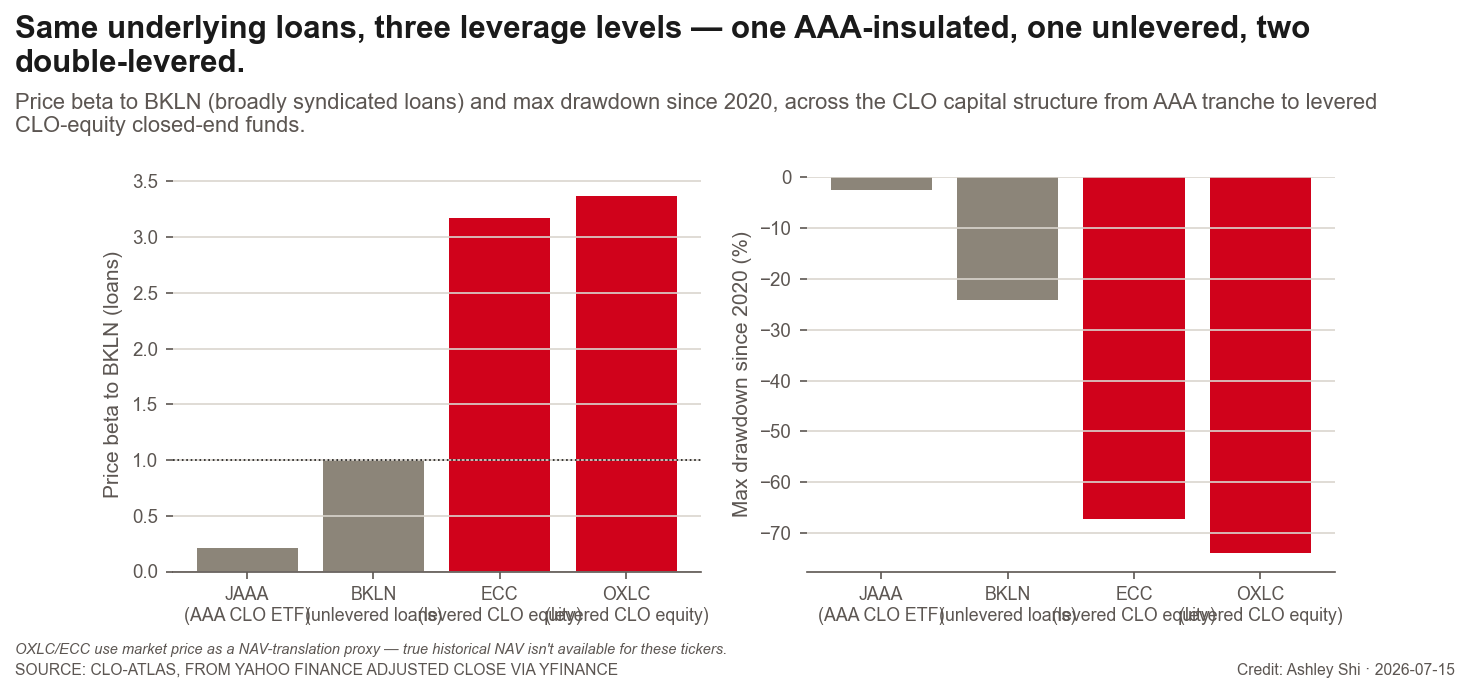

In [4]:
viz_flywheel.run()
viz_cost_of_capital.run()
viz_distribution.run()
viz_style.run()
viz_wrapper.run()


## Exhibits

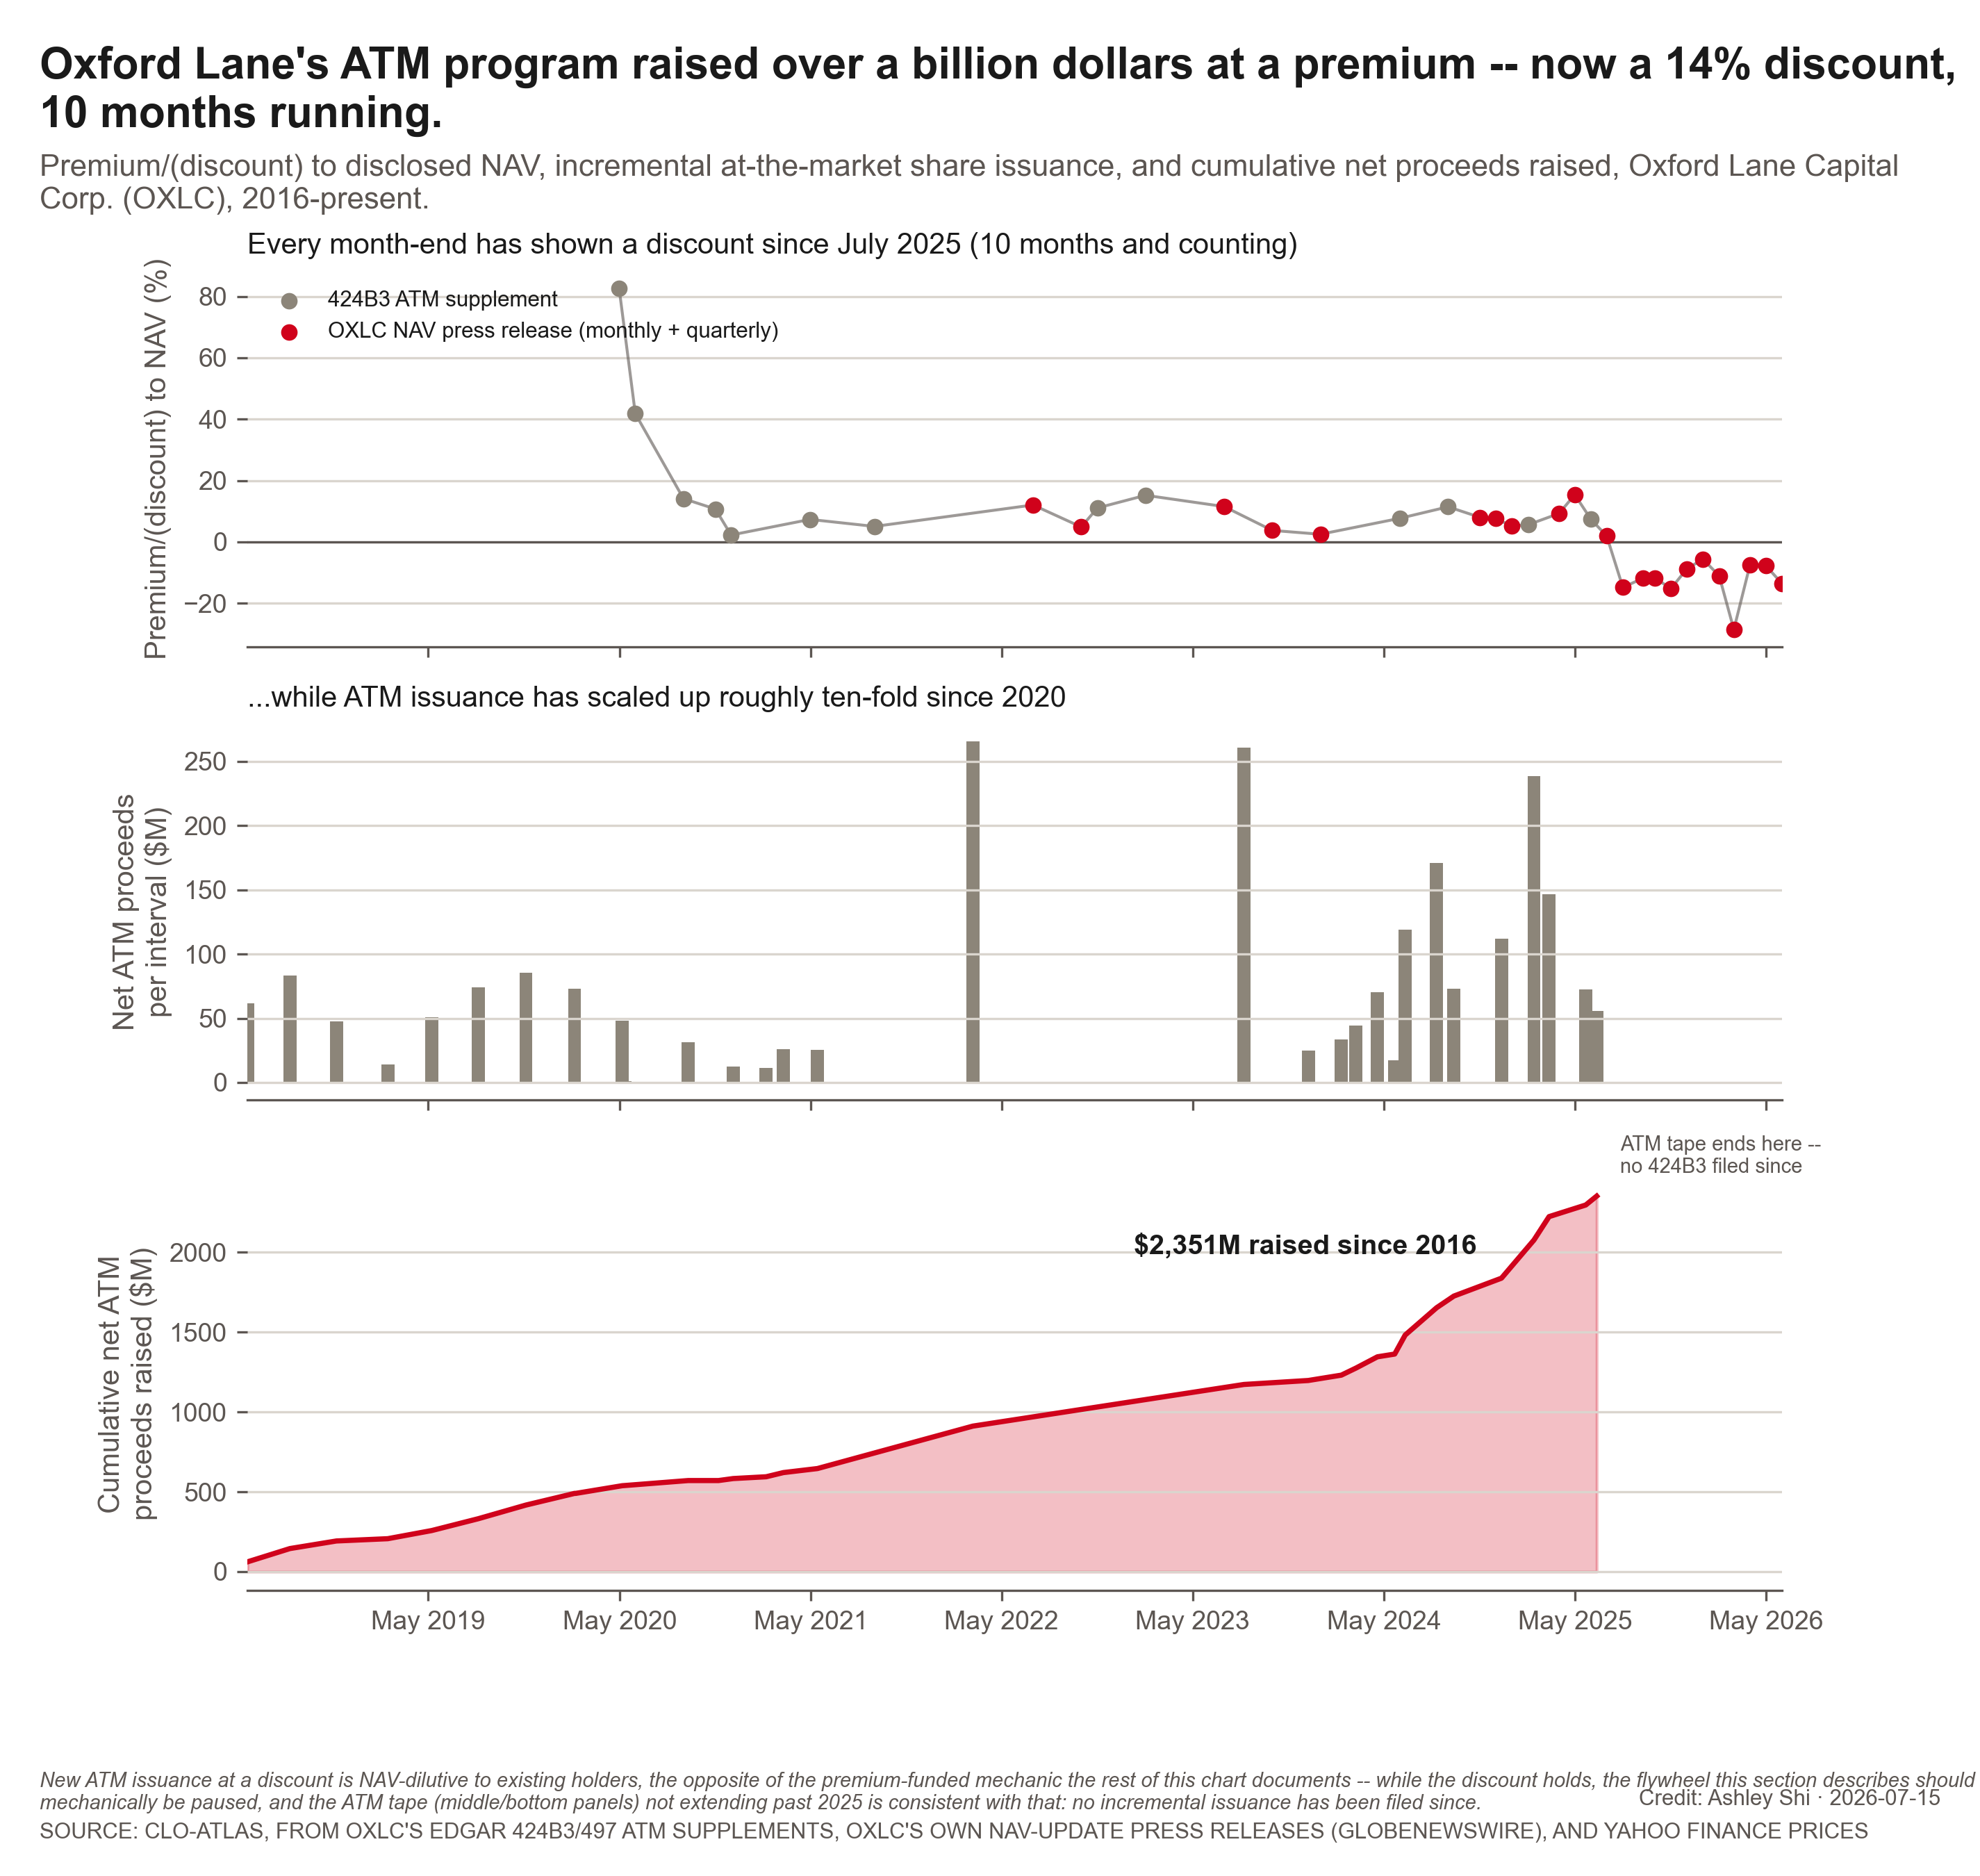

In [5]:
path = pathlib.Path("../figures") / "viz_flywheel.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_flywheel")


**VERIFIED**: two independent, real OXLC NAV disclosure channels, merged. The first is EDGAR 424B3/497 prospectus supplements (exact ATM shares sold and net proceeds since the prior supplement, plus scattered month-end NAV-per-share estimates) — but that channel is tied to ATM activity and goes quiet whenever issuance does, which is exactly what happened after May 2025. The second, added in this pass, is OXLC's own monthly and quarterly NAV-update press releases (GlobeNewswire), which don't depend on ATM activity and kept disclosing straight through 2025 and into 2026 (`scrape_nav_press_releases.py`). Both are joined against Yahoo Finance market price (corrected for OXLC's 2025-09-08 1-for-5 reverse split, keyed off each figure's own publication date rather than its as-of date — see the intro cell above and the ledger's bug-fix rows below) to produce one continuous real premium/discount series, 2020-present.

Three aligned panels on one time axis show the result: OXLC's premium/discount to disclosed NAV at every observed date (gray = 424B3 supplement, red = press release), incremental ATM proceeds raised per interval, and the cumulative total — **$2,351M raised since 2016**. The mechanism, while it holds: retail demand bids OXLC's shares up above NAV, and the company sells new shares into that premium, converting it directly into fresh primary-market CLO-equity buying power. **It has not held since July 2025.** Every month-end since then — 10 straight readings through the most recent (May 2026) release — has shown a real discount, not a premium, bottoming near -29% in February 2026 and running about -14% most recently. New ATM issuance at a discount is NAV-dilutive to existing holders, the opposite of what the flywheel needs, and the ATM-issuance panel (middle) going quiet exactly when the discount starts is consistent with that: no 424B3 has been filed since the disclosure trail's last point, meaning the fund appears to have actually stopped issuing into the discount rather than continuing anyway.

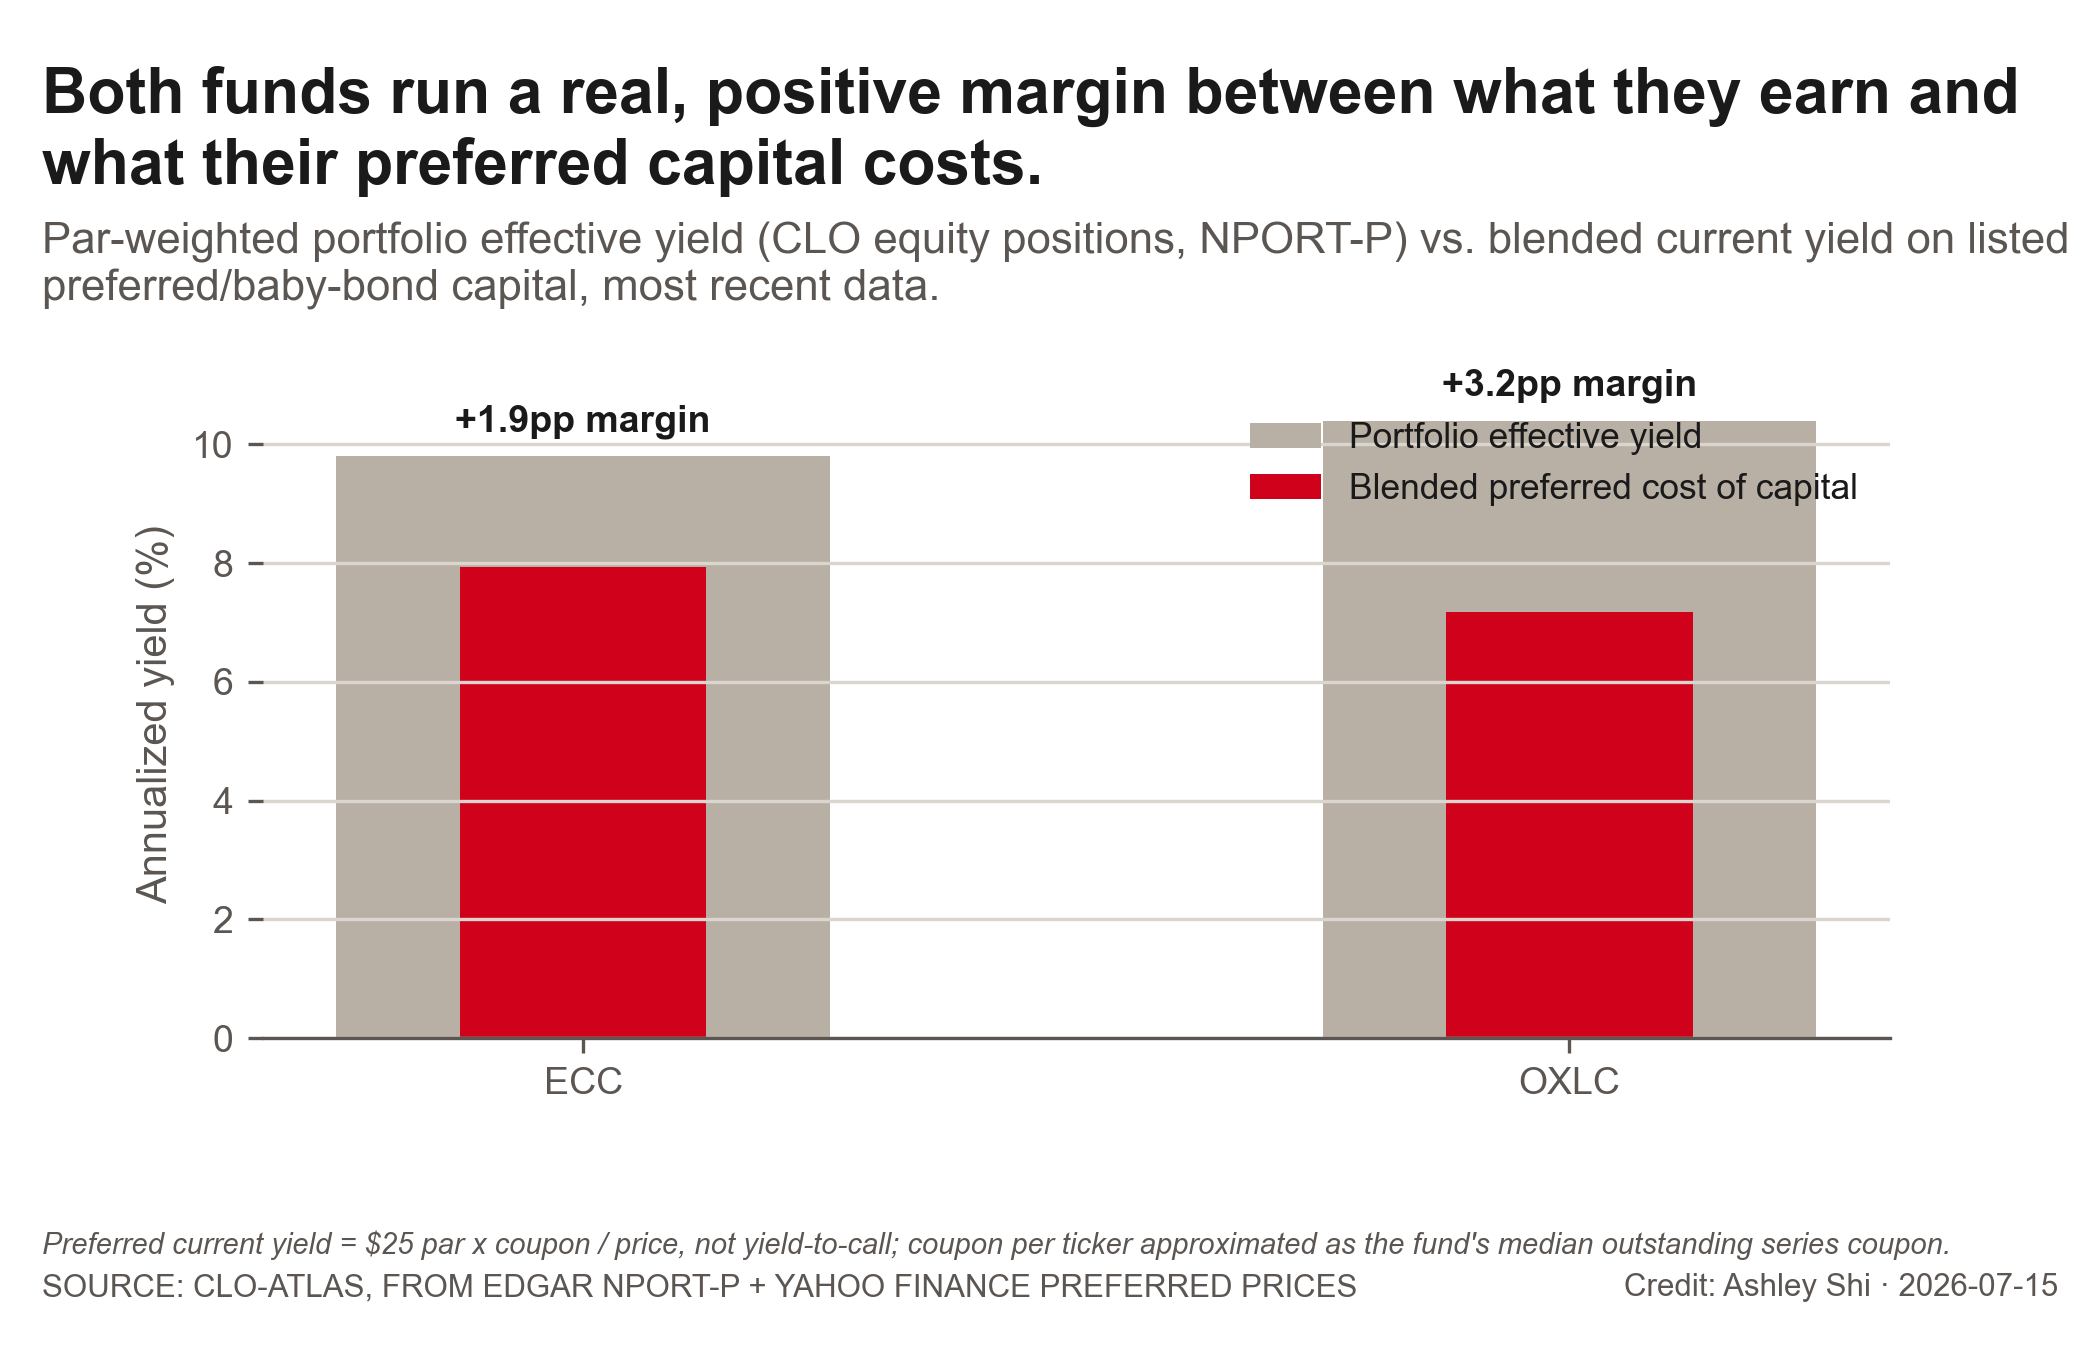

In [6]:
path = pathlib.Path("../figures") / "viz_cost_of_capital_margin.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_cost_of_capital_margin")


**VERIFIED**: par-weighted portfolio effective yield on CLO-equity positions (EDGAR NPORT-P) against blended current yield on each fund's listed preferred/baby-bond capital (Yahoo Finance prices; coupon approximated as the fund's median outstanding series coupon, current yield not yield-to-call). The bar chart pairs the two yields for ECC (portfolio yield 9.8%) and OXLC (10.4%) against each fund's own blended preferred cost, with the margin annotated directly on each pair. That spread is the un-narrated mechanism behind the CEF wrapper: both funds earn a real, positive margin borrowing at preferred rates and investing in CLO equity, which is the leverage engine that makes CLO-CEF distributions possible in the first place.

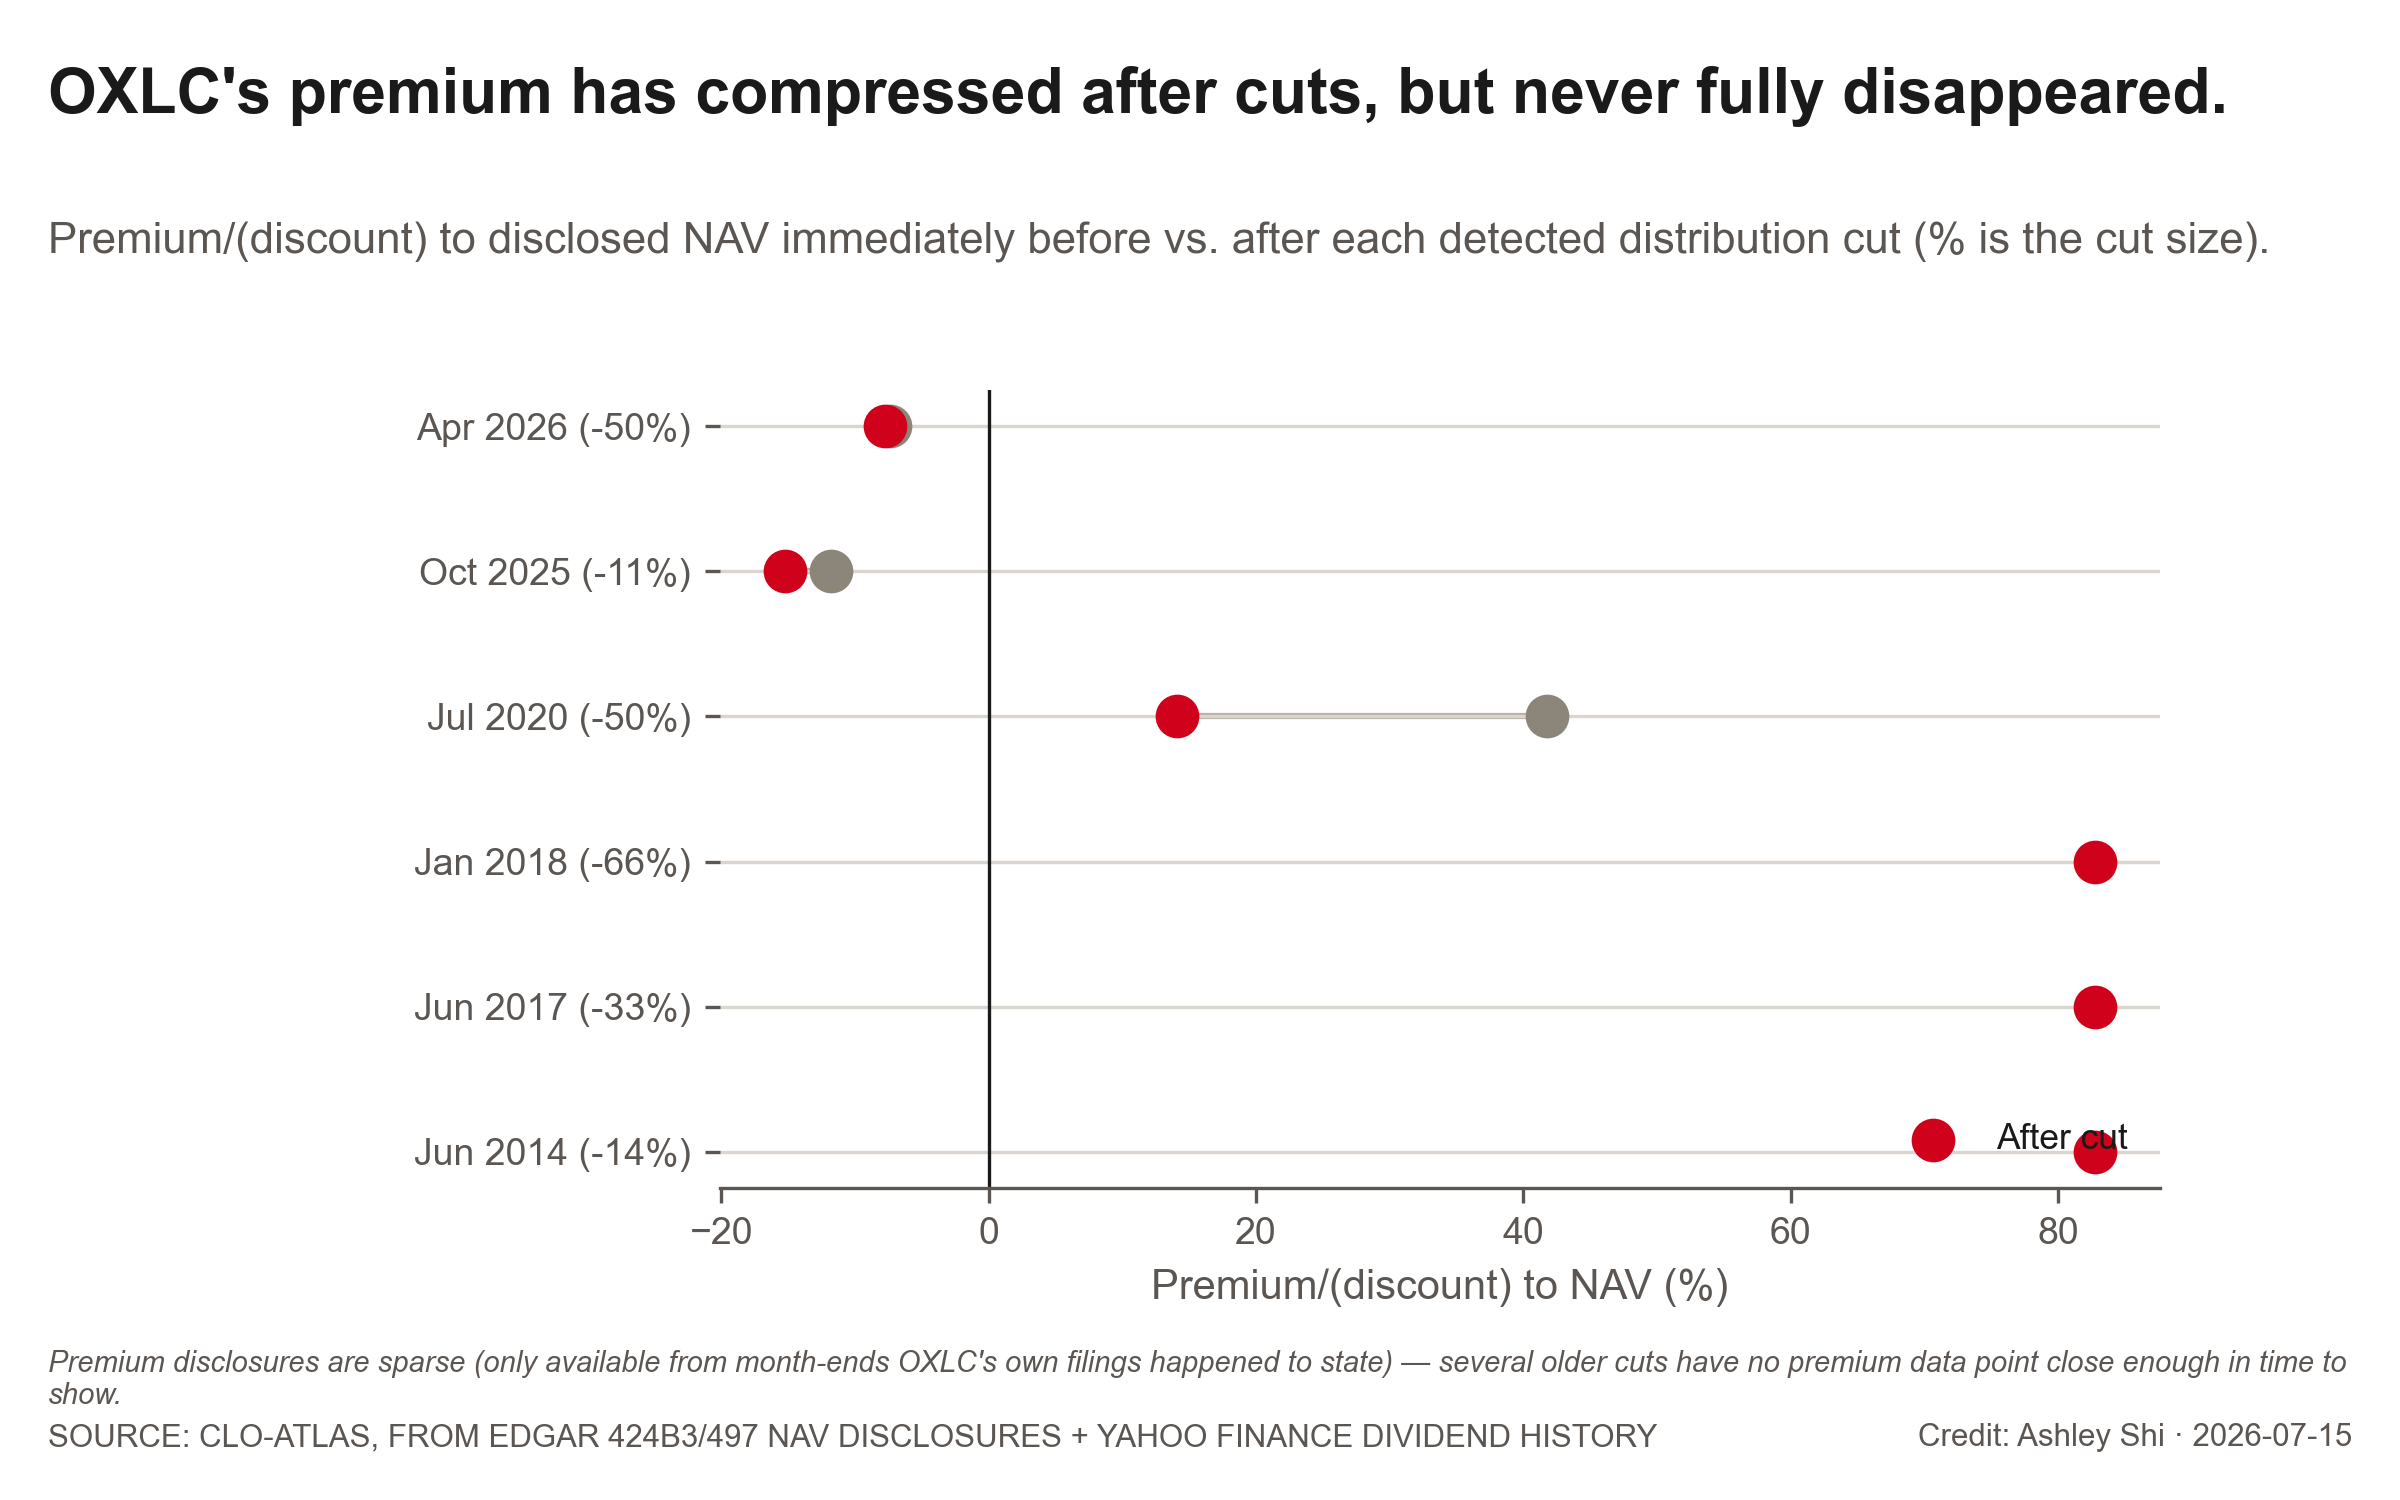

In [7]:
path = pathlib.Path("../figures") / "viz_distribution_cuts_vs_premium.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_distribution_cuts_vs_premium")


**VERIFIED**: OXLC's premium/discount to disclosed NAV immediately before vs. after each detected distribution cut, from the same EDGAR 424B3/497 NAV disclosures and Yahoo Finance dividend history used in the flywheel exhibit — though premium data points are sparse, tied only to month-ends the filings happened to state, so several older cuts have no close-enough data point to plot. Each row is one cut, sized by percentage change, with a line connecting the premium before and after. The premium compresses after a cut but never fully disappears, which answers a natural skeptic's question about the flywheel chart above: distribution cuts erode, but don't kill, the premium that funds OXLC's ATM issuance.

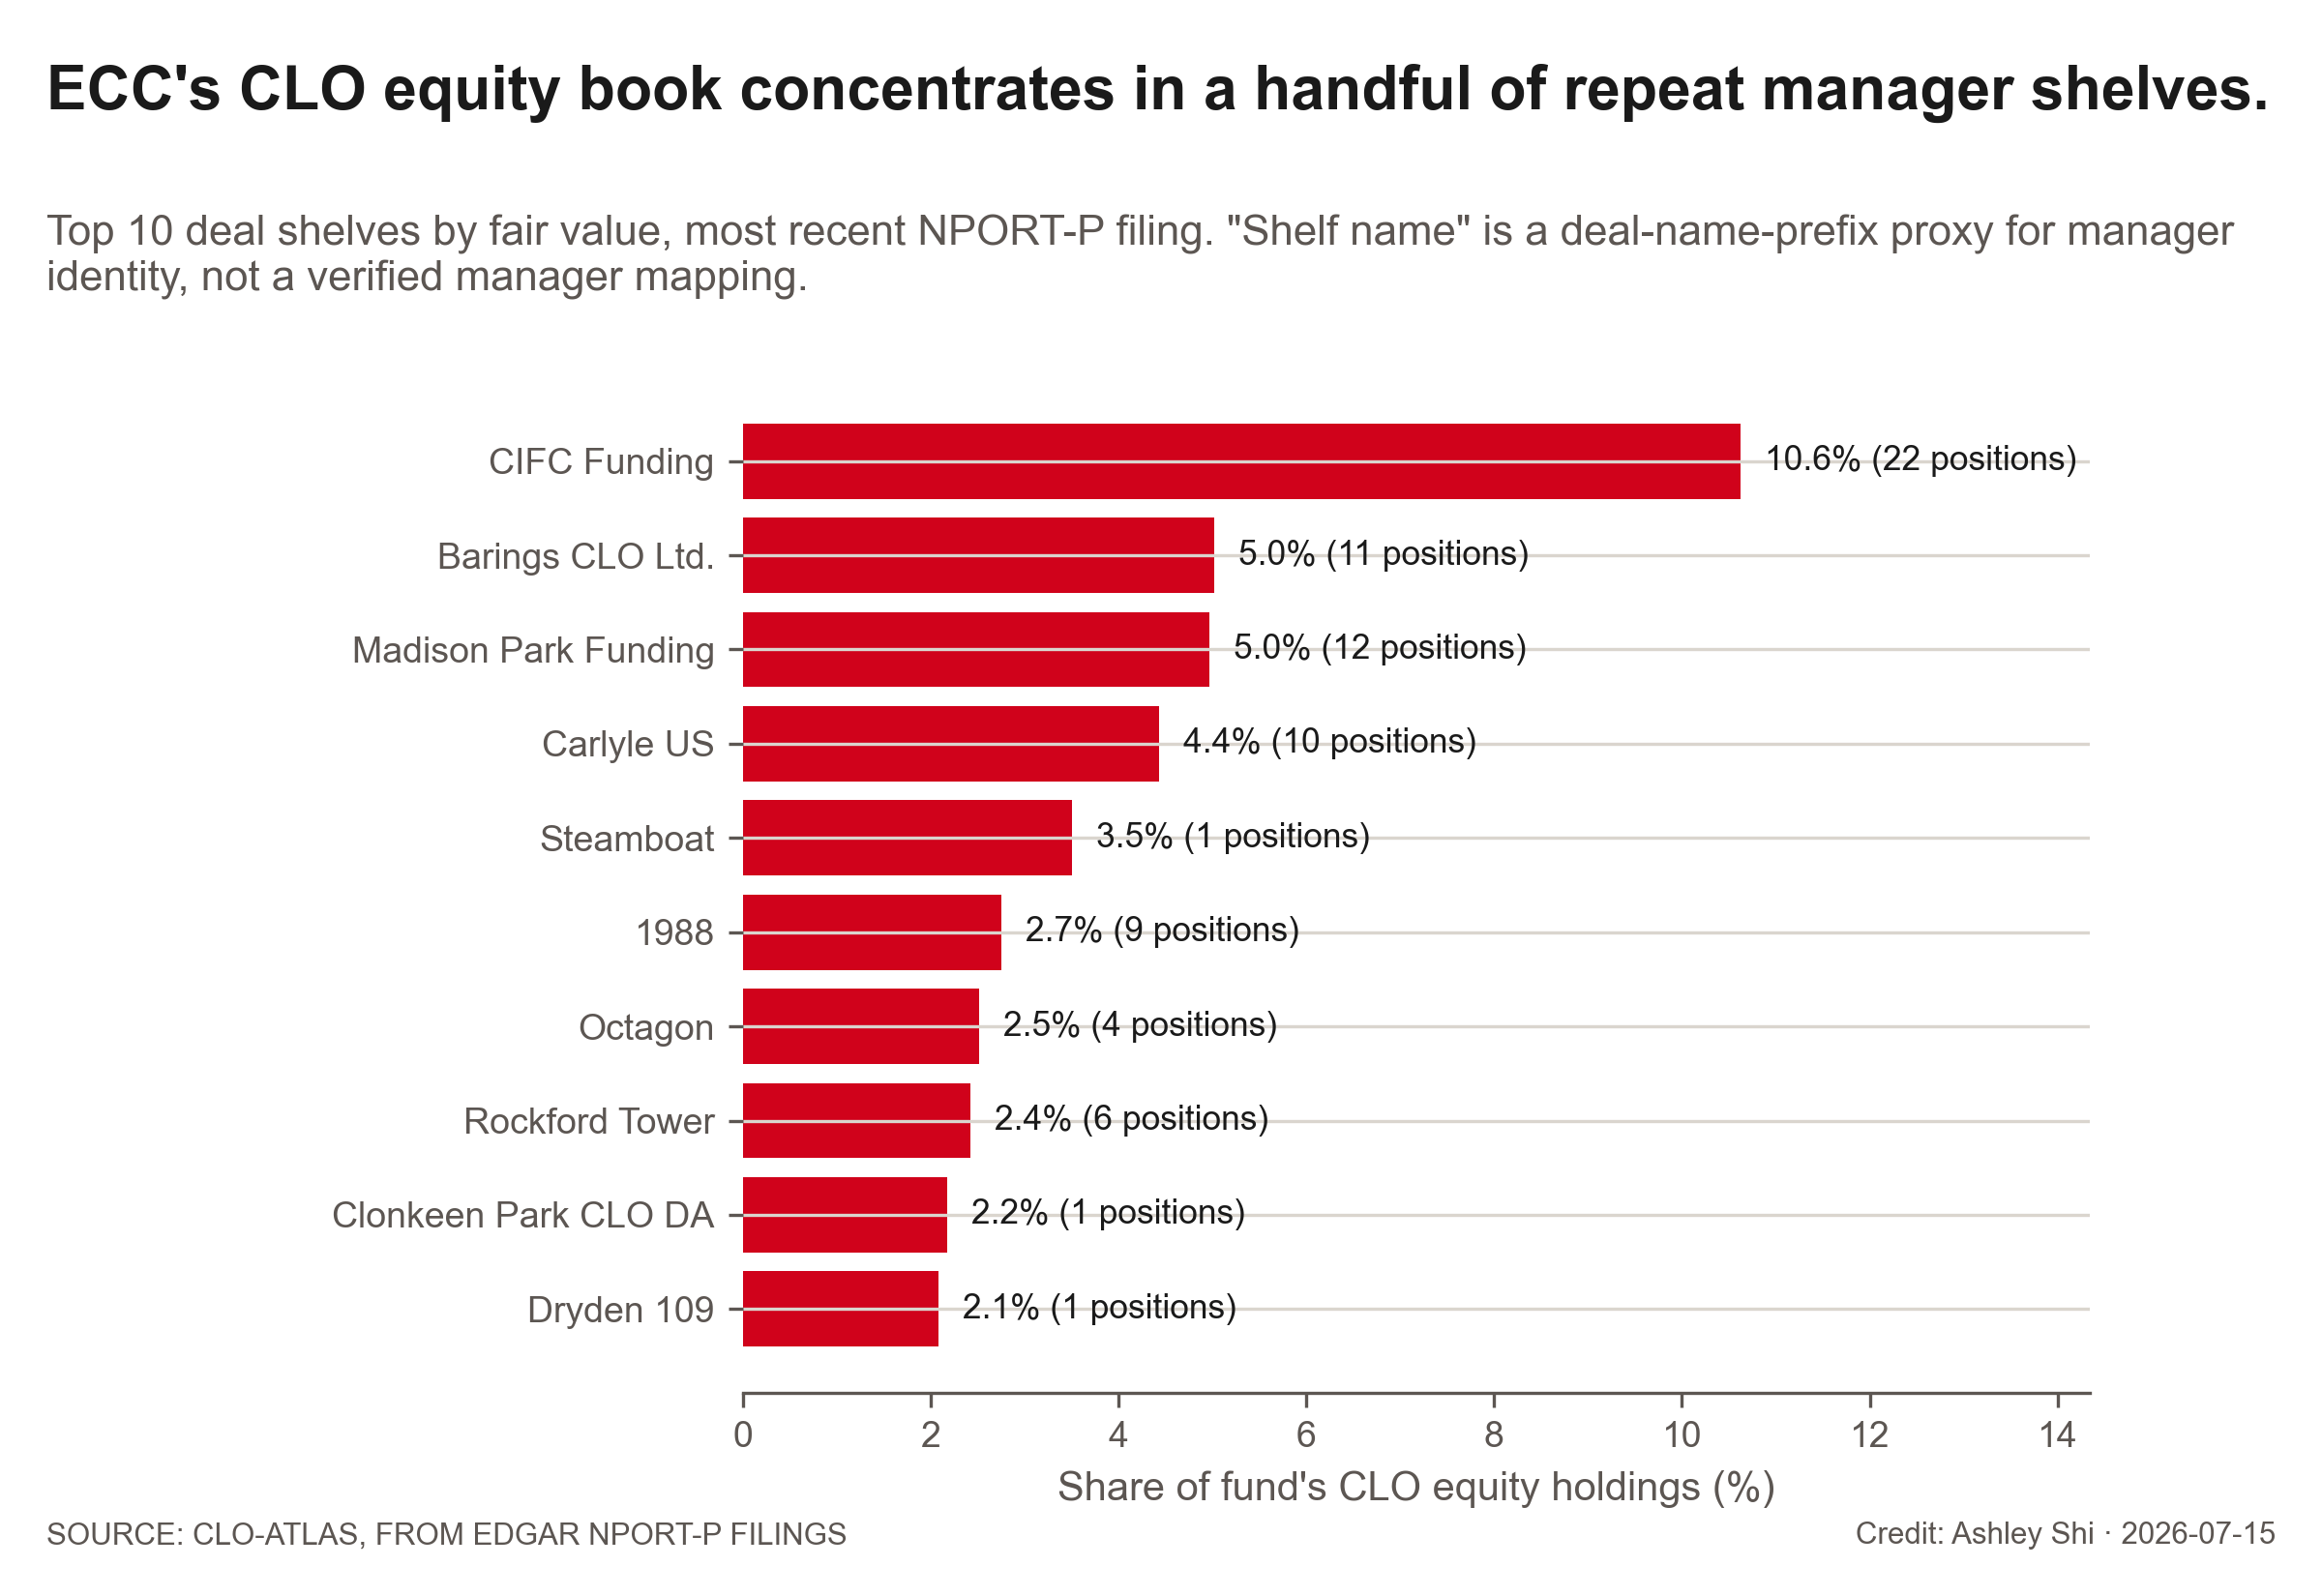

In [8]:
path = pathlib.Path("../figures") / "viz_shelf_concentration.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_shelf_concentration")


**VERIFIED**, with a named proxy caveat: fair value by CLO deal shelf from ECC's most recent NPORT-P filing, where "shelf name" is a deal-name-prefix heuristic standing in for CLO manager identity, not a verified issuer-to-manager mapping (`analysis_portfolio_style.py`). The horizontal bar chart ranks ECC's top 10 shelves by share of the fund's total CLO-equity holdings, with position counts annotated per bar. It shows that even a diversified CLO-equity CEF concentrates in a handful of repeat manager relationships — a reminder that "CLO equity" as an asset class is really manager-selection risk wrapped inside a fund structure.

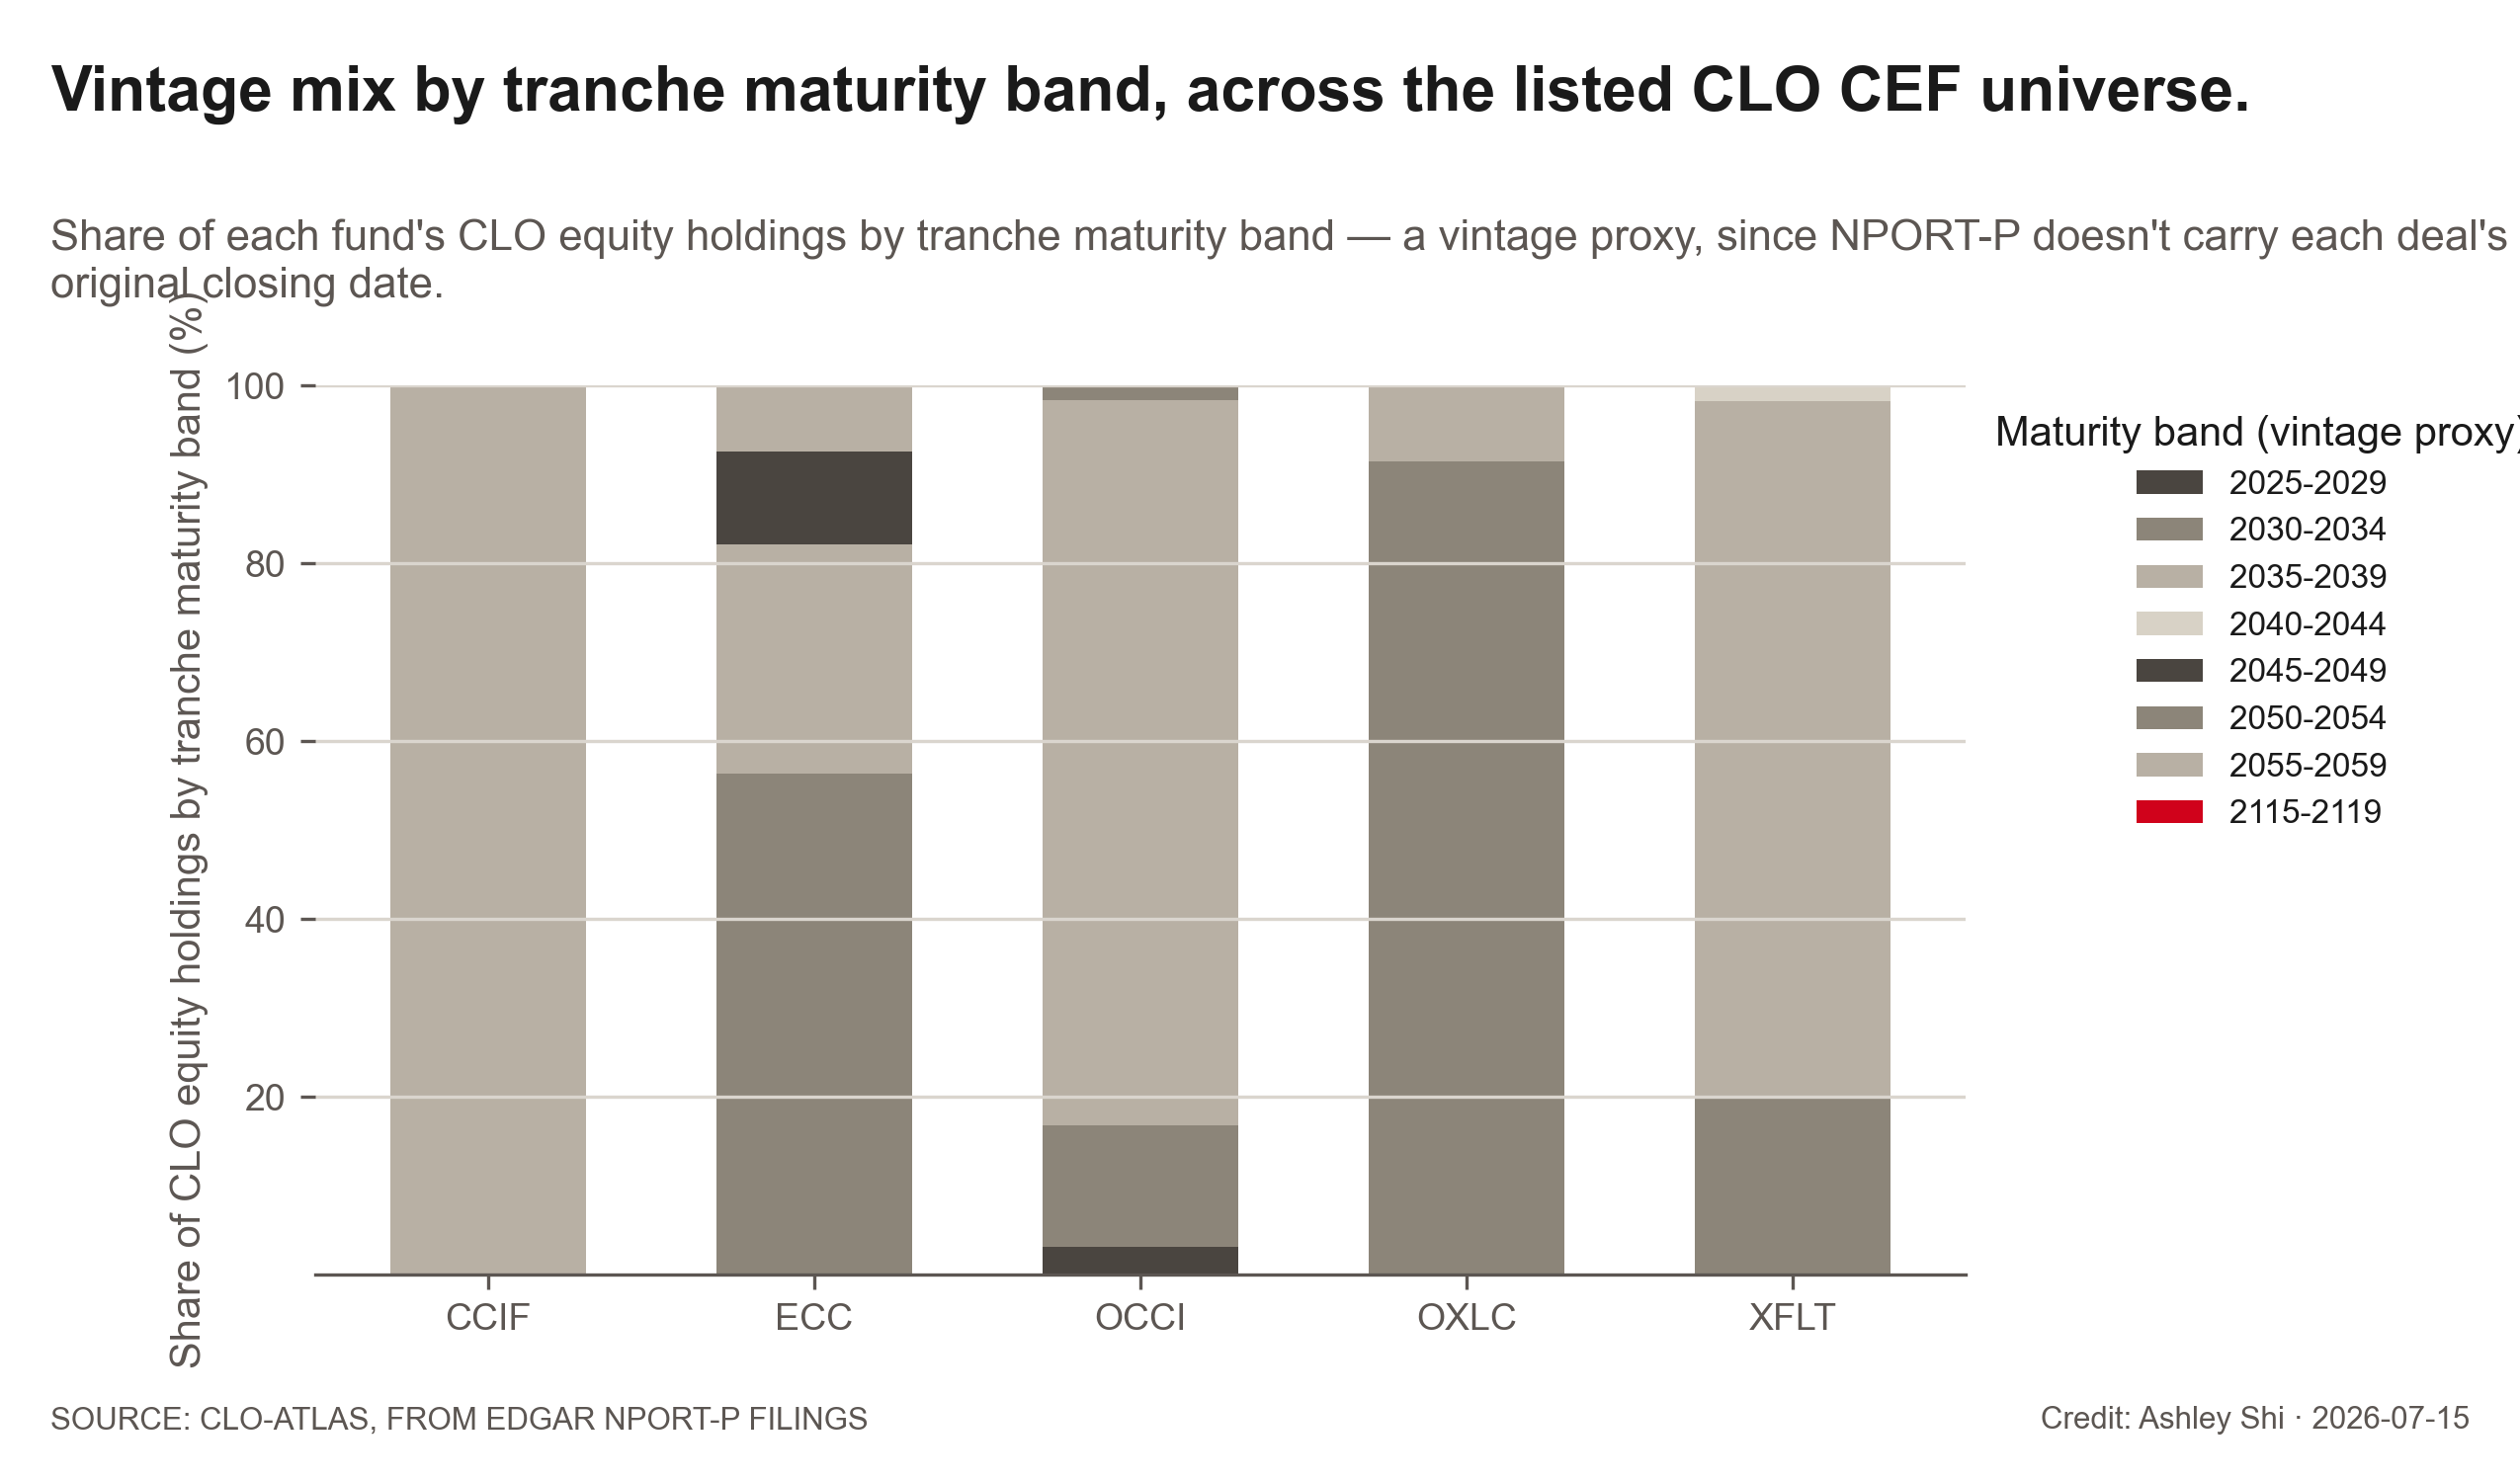

In [9]:
path = pathlib.Path("../figures") / "viz_vintage_mix.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_vintage_mix")


**VERIFIED**: share of each fund's CLO-equity holdings by tranche maturity band, from EDGAR NPORT-P filings — used here as a vintage proxy, since NPORT-P doesn't disclose each deal's original closing date. The stacked bar chart compares maturity-band composition across the tracked CLO CEF universe, one bar per fund. Maturity-band mix is a rough stand-in for how exposed each fund is to CLOs originated in different rate/spread environments — a genuine risk differentiator between funds that otherwise look similar on yield alone.

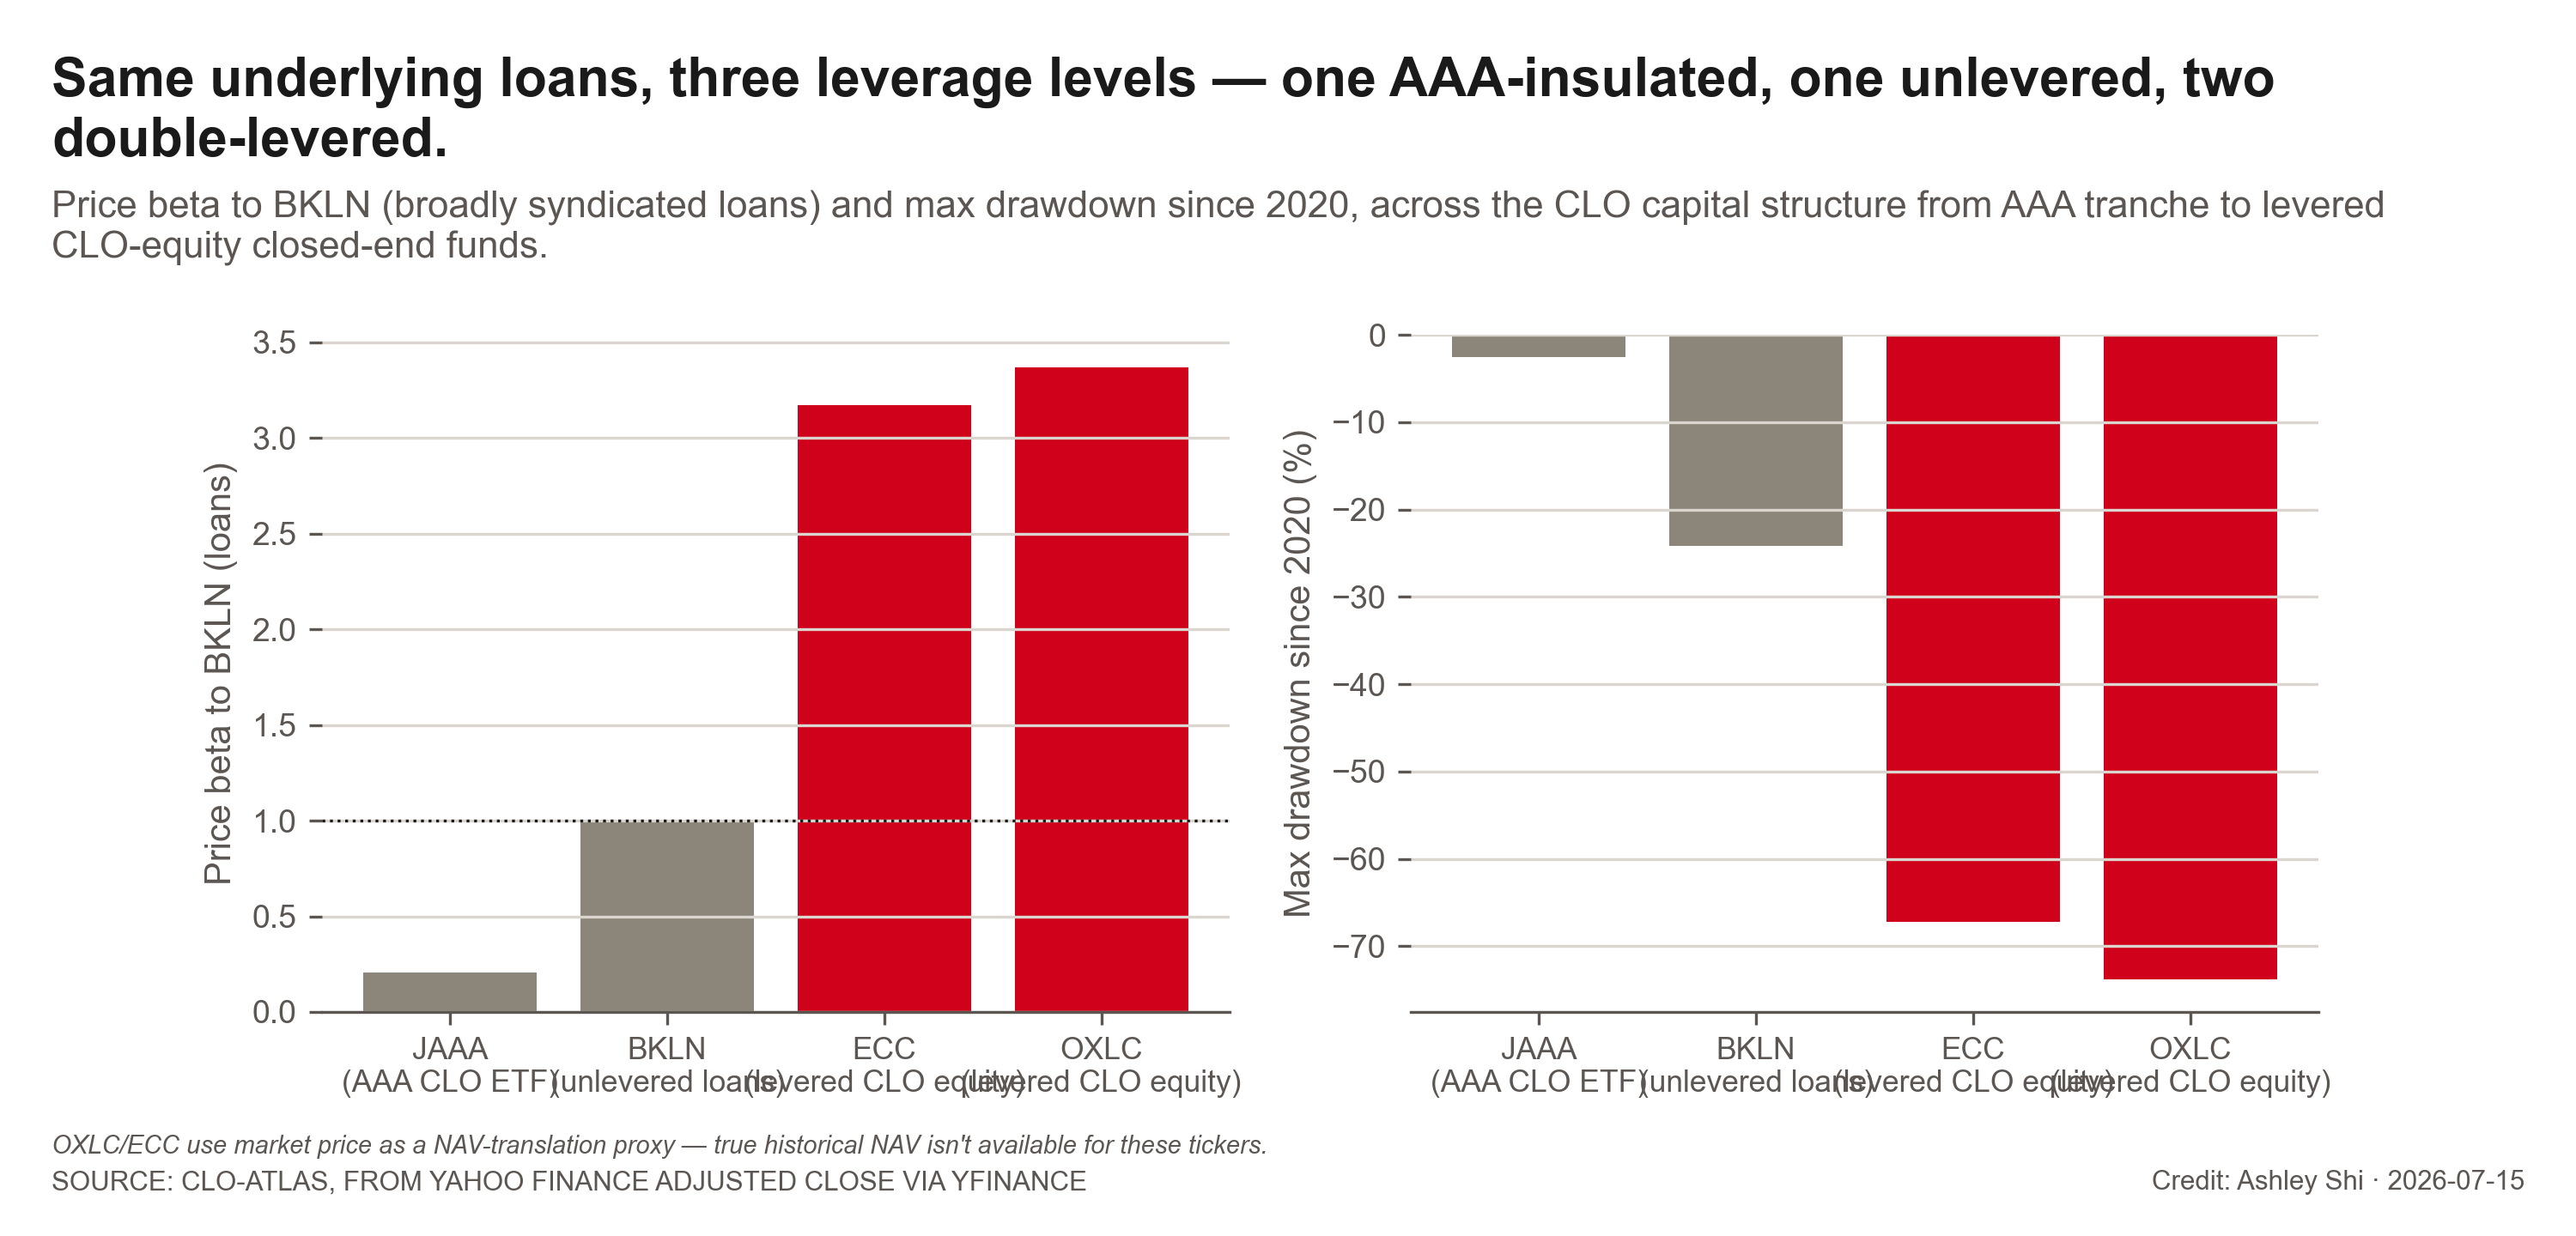

In [10]:
path = pathlib.Path("../figures") / "viz_leverage_gradient.png"
if path.exists():
    display(Image(filename=str(path)))
else:
    print("[skipped — not generated this run] viz_leverage_gradient")


**VERIFIED**: price beta to BKLN (unlevered broadly syndicated loans) and max drawdown since 2020, computed from Yahoo Finance adjusted-close history for JAAA, BKLN, ECC, and OXLC (OXLC/ECC use market price as a NAV-translation proxy, since true historical NAV isn't available for these tickers). Two panels place all four instruments on the same axis: JAAA's beta to loans near 0.21 (AAA-tranche insulation), BKLN at 1.00 by construction, and ECC/OXLC both above 3x (double-levered CLO equity). Lined up like this, the four tickers teach the entire CLO capital structure through instruments an ordinary brokerage account can actually buy — same underlying loan collateral, wildly different risk depending on where in the stack the capital sits.

## VERIFIED / TO-VERIFY ledger

Every number appearing in this section's exhibits, including the split-adjustment bug fix and the demand-transmission chain's stated gap.

In [11]:
cef_deep_dive_ledger = ledger.run()
cef_deep_dive_ledger


,value,computation_or_citation,as_of,tag
0,"$2,351M raised via OXLC's ATM program since 2016",analysis_capital_machine.incremental_issuance(...,2025-06-11 00:00:00,VERIFIED
1,Disclosed premium/discount ranges -29% to 83%;...,"analysis_capital_machine.premium_history(), me...",2026-05-31 00:00:00,VERIFIED
2,Bug caught and fixed: unrescaled comparison ag...,see analysis_capital_machine.py docstring and ...,n/a,VERIFIED
3,Second bug caught and fixed: a press release p...,see analysis_capital_machine.py docstring and ...,n/a,VERIFIED
4,ECC: portfolio yield 9.8% vs. blended preferre...,analysis_cost_of_capital.cost_of_capital_margin(),n/a,VERIFIED
5,OXLC: portfolio yield 10.4% vs. blended prefer...,analysis_cost_of_capital.cost_of_capital_margin(),n/a,VERIFIED
6,JAAA: price beta to BKLN = 0.21,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
7,OXLC: price beta to BKLN = 3.37,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
8,ECC: price beta to BKLN = 3.17,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
9,BKLN: price beta to BKLN = 1.00,analysis_nav_translation.price_beta_to_loans()...,n/a,VERIFIED
